# KPI Anomaly Detection Agent — Master Dataset EDA

Exploratory Data Analysis of `data/master_dataset.csv`.
**731 daily rows · 33 columns · 20 labeled anomaly events · 2 years of data (2024–2025)**

| Section | What it covers |
|---|---|
| 1 | Dataset shape & first 5 rows |
| 2 | Column types & non-null counts |
| 3 | Descriptive statistics |
| 4 | Missing values & dtype summary |
| 5 | Anomaly label distribution |
| 6 | Skewness analysis |
| 7 | Distribution histograms (27 metrics) |
| 8 | EDA summary & detection implications |

---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('data/master_dataset.csv', parse_dates=['date'])
print(f"Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns")

Dataset loaded: 731 rows x 33 columns


## 1. Dataset Shape & First 5 Rows

`df.shape` confirms 731 daily rows and 33 columns covering 2 full years (2024-01-01 to 2025-12-31).
`df.head()` shows the structure — each row is one calendar day aggregated across all channels.

In [ ]:
print('Shape:', df.shape)
df.head()

Shape: (731, 33)


,date,n_orders,total_revenue_usd,avg_order_value_usd,avg_discount_pct,n_unique_customers,n_returns,return_rate,total_spend_usd,total_impressions,total_clicks,total_conversions_marketing,total_attributed_revenue_usd,avg_roas,sessions,unique_visitors,bounce_rate,pages_per_session,avg_session_duration_sec,conversion_rate,conversions_web,total_stock_on_hand,total_units_sold,n_stockouts,n_reorders,economic_index,marketing_pressure,consumer_sentiment,seasonal_index,inventory_health,anomaly_flag,anomaly_event,anomaly_kpi
0,2024-01-01,194,10670.00,55.00,0.07,153,15,0.0773,12149.64,2223769,84269,2479,486130.85,40.012,7706,6486,0.411,3.19,162.9,0.0250,192,50000,326,0,1,0.00000,0.00000,0.00000,-0.14668,0.00000,0,NaN,NaN
1,2024-01-02,197,11219.00,56.95,0.07,158,15,0.0761,12623.89,2158313,52190,6109,1117332.31,88.509,7759,6552,0.411,3.39,189.3,0.0246,190,50045,275,0,2,0.06497,-0.02917,0.05366,-0.14612,0.00303,0,NaN,NaN
2,2024-01-03,195,10950.54,56.16,0.07,140,15,0.0769,11628.20,1864903,51258,5293,804760.51,69.208,7739,5958,0.402,3.29,183.5,0.0245,189,50490,307,0,1,0.03855,-0.03019,0.06407,-0.14551,0.03267,0,NaN,NaN
3,2024-01-04,184,10209.82,55.49,0.07,146,14,0.0761,12705.53,2091582,86234,5682,744334.00,58.583,7723,5733,0.474,2.95,199.9,0.0223,172,49534,356,0,0,0.01627,-0.17671,0.06376,-0.14486,-0.03101,0,NaN,NaN
4,2024-01-05,189,10241.14,54.19,0.07,134,15,0.0794,11597.88,1496398,66045,2865,141325.98,12.186,7689,5882,0.426,3.39,170.6,0.0243,186,50214,419,0,0,-0.02714,-0.04422,0.00467,-0.14417,0.01433,0,NaN,NaN


## 2. Column Types & Non-Null Counts

`df.info()` shows the dtype and non-null count for all 33 columns.

**Key observations:**
- `date` — loaded as `datetime64[ns]` after `parse_dates=['date']`
- `anomaly_event` and `anomaly_kpi` — only **20 non-null** entries (the labeled anomaly days); all others are `NaN`
- All 30 KPI columns are **fully populated** (zero nulls) — no imputation required
- **14 integer** columns, **16 float** columns, **3 object/string** columns

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   date                          731 non-null    datetime64[us]
 1   n_orders                      731 non-null    int64         
 2   total_revenue_usd             731 non-null    float64       
 3   avg_order_value_usd           731 non-null    float64       
 4   avg_discount_pct              731 non-null    float64       
 5   n_unique_customers            731 non-null    int64         
 6   n_returns                     731 non-null    int64         
 7   return_rate                   731 non-null    float64       
 8   total_spend_usd               731 non-null    float64       
 9   total_impressions             731 non-null    int64         
 10  total_clicks                  731 non-null    int64         
 11  total_conversions_marketing   731 non-null 

## 3. Descriptive Statistics

`df.describe().T` — transposed so each KPI is a row for easier reading.

**Key observations:**

| KPI | Observation |
|---|---|
| `total_revenue_usd` | Mean $11,715 but max $66,133 — anomaly spikes inflate the right tail |
| `avg_roas` | Mean 34.1 but max 164.6 — marketing campaign anomalies cause extreme values |
| `sessions` | Mean 8,390 but max 46,935 — bot traffic / viral events create extreme outliers |
| `avg_order_value_usd` | Mean $57.4, max $213.3 — fraud or high-value order anomalies |
| `conversion_rate` | Tight range 0.018–0.039, mean 0.024 — most stable Tier 1 metric |
| `return_rate` | Mean 7.7%, max 23.4% — defective product events drive extreme peaks |
| External drivers | `economic_index`, `seasonal_index`, `consumer_sentiment` all centred near 0 — by design |

In [ ]:
df.describe().T.round(3)

,count,mean,min,25%,50%,75%,max,std
date,731,2024-12-31 00:00:00,2024-01-01 00:00:00,2024-07-01 12:00:00,2024-12-31 00:00:00,2025-07-01 12:00:00,2025-12-31 00:00:00,NaN
n_orders,731.0,202.577291,125.0,192.0,201.0,212.0,370.0,17.574592
total_revenue_usd,731.0,11715.435691,7207.53,10404.5,11365.35,12456.73,66133.01,3336.585109
avg_order_value_usd,731.0,57.38197,49.17,53.89,56.83,59.54,213.33,9.642618
avg_discount_pct,731.0,0.07522,0.07,0.07,0.07,0.078,0.123,0.00927
n_unique_customers,731.0,145.74829,100.0,132.0,144.0,158.0,252.0,19.020742
n_returns,731.0,15.651163,9.0,14.0,15.0,17.0,47.0,2.053412
return_rate,731.0,0.077218,0.0619,0.0743,0.0776,0.08,0.2338,0.007232
total_spend_usd,731.0,12786.93275,11099.92,12079.88,12766.87,13390.045,22446.8,988.296166
total_impressions,731.0,1786812.670315,902969.0,1388652.0,1747232.0,2147290.0,3922510.0,477170.756547


## 4. Missing Values & Data Types

Combined view: dtype, null count, and null percentage per column.

**Only `anomaly_event` and `anomaly_kpi` have nulls** — 711 out of 731 rows (97.3%) are `NaN` because those columns only populate on anomaly days.
This is expected by design, not a data quality issue.

In [ ]:
null_counts = df.isnull().sum().rename('null_count')
dtypes      = df.dtypes.rename('dtype')
summary = pd.concat([dtypes, null_counts], axis=1)
summary['null_%'] = (summary['null_count'] / len(df) * 100).round(1)
summary

,dtype,null_count,null_%
date,datetime64[us],0,0.0
n_orders,int64,0,0.0
total_revenue_usd,float64,0,0.0
avg_order_value_usd,float64,0,0.0
avg_discount_pct,float64,0,0.0
n_unique_customers,int64,0,0.0
n_returns,int64,0,0.0
return_rate,float64,0,0.0
total_spend_usd,float64,0,0.0
total_impressions,int64,0,0.0


## 5. Anomaly Label Distribution

The dataset contains **20 labeled anomaly days** out of 731 total — a **2.7% anomaly rate**.

**Implications:**
- This class imbalance means a naive classifier that predicts "normal" every day achieves 97.3% accuracy — use **precision/recall**, not accuracy, to evaluate detectors
- Set `contamination=0.027` in Isolation Forest to match the true anomaly rate
- Use the 20 labeled rows as ground truth to tune detection thresholds (optimise for recall on Tier 1 KPIs)

**14 distinct event types** are labeled — ranging from demand spikes to fraud attacks and external macro shocks.

In [ ]:
print("=== anomaly_flag ===")
print(df['anomaly_flag'].value_counts().rename({0: 'Normal (0)', 1: 'Anomaly (1)'}))
print(f"\nAnomaly rate: {df['anomaly_flag'].mean()*100:.1f}%")

print("\n=== anomaly_event (20 labeled events) ===")
print(df['anomaly_event'].value_counts())

print("\n=== anomaly_kpi (which KPI each event affects) ===")
print(df['anomaly_kpi'].value_counts())

=== anomaly_flag ===
anomaly_flag
Normal (0)     711
Anomaly (1)     20

Anomaly rate: 2.7%

=== anomaly_event (20 labeled events) ===
anomaly_event
inventory_stockout           2
fraud_attack                 2
bot_traffic_surge            2
black_friday_spike           2
cyber_monday_halo            2
influencer_campaign          2
economic_sentiment_drop      1
logistics_disruption         1
website_outage               1
marketing_tracking_outage    1
defective_product_returns    1
back_to_school_surge         1
email_campaign_spike         1
coupon_abuse                 1

=== anomaly_kpi (which KPIs are flagged) ===
anomaly_kpi
revenue             4
sales_volume        3
sessions            3
refunds             2
new_customers       2
aov                 1
fulfillment_time    1
roas                1
return_rate         1
conversion_rate     1
discount_rate       1


## 6. Skewness Analysis

Skewness measures how asymmetric each distribution is:

| Range | Interpretation | Detection implication |
|---|---|---|
| > 0.5 | Right-skewed (long right tail) | Log-transform or rolling Z-score before detection |
| < -0.5 | Left-skewed (long left tail) | Reflect + log-transform before detection |
| -0.5 to 0.5 | Approximately normal | Direct Z-score thresholding (±2.5σ) is valid |

**16 of 27 continuous columns are right-skewed** — the extreme anomaly events (Black Friday, bot traffic, fraud) pull the right tail far from the mean.
**11 columns are approximately normal** — external drivers and stable operational metrics.

In [ ]:
exclude = ['anomaly_flag', 'n_stockouts', 'n_reorders']
cont_cols = [c for c in df.select_dtypes(include='number').columns if c not in exclude]

skew = df[cont_cols].skew().round(3).sort_values(ascending=False).rename('skewness')
skew_df = skew.to_frame()
skew_df['shape'] = skew_df['skewness'].apply(
    lambda s: 'RIGHT-SKEWED' if s > 0.5 else ('LEFT-SKEWED' if s < -0.5 else 'Approx. Normal')
)
skew_df

,skewness,shape
sessions,17.267,RIGHT-SKEWED
unique_visitors,15.425,RIGHT-SKEWED
return_rate,13.824,RIGHT-SKEWED
avg_order_value_usd,12.603,RIGHT-SKEWED
total_revenue_usd,11.360,RIGHT-SKEWED
conversions_web,11.153,RIGHT-SKEWED
n_returns,5.324,RIGHT-SKEWED
avg_discount_pct,2.223,RIGHT-SKEWED
n_orders,1.694,RIGHT-SKEWED
total_spend_usd,1.662,RIGHT-SKEWED


## 7. Distribution Histograms — All 27 Continuous Metrics

**How to read:**
- Each subplot = one KPI column
- Title shows: column name · skewness value · distribution label
- **Red bars** → skewed (|skew| > 0.5) — consider log-transform before applying statistical detection
- **Green bars** → approximately normal — Z-score thresholding applies directly
- Extreme right-tail bars in skewed charts correspond to the 20 labeled anomaly days

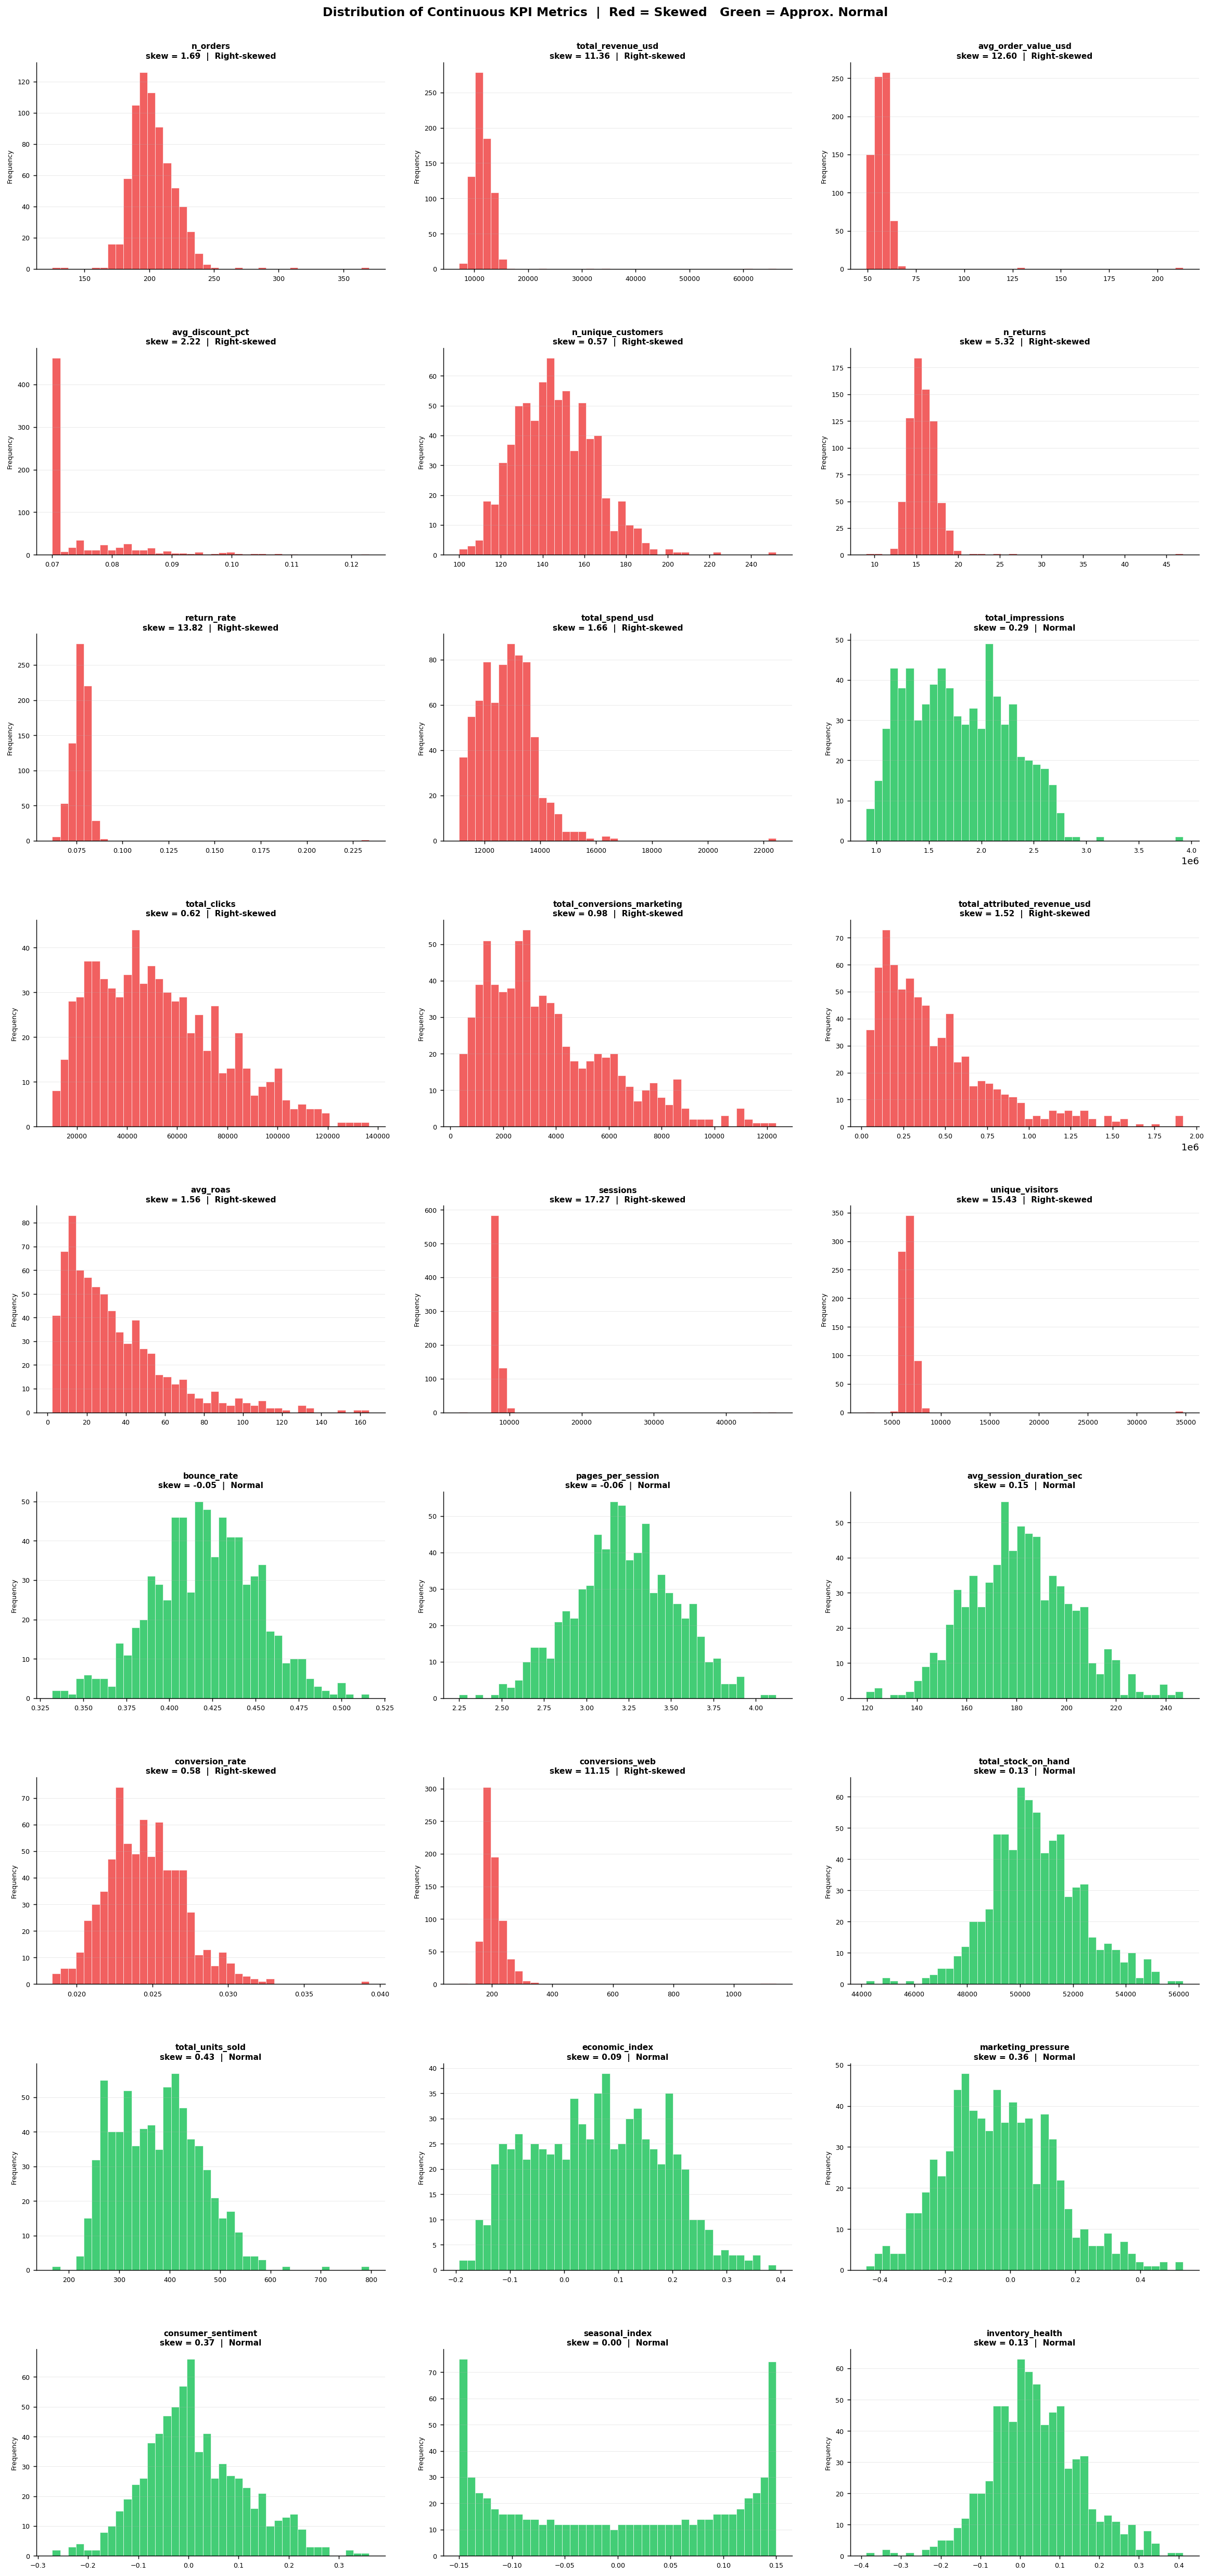

In [ ]:
exclude = ['anomaly_flag', 'n_stockouts', 'n_reorders']
cont_cols = [c for c in df.select_dtypes(include='number').columns if c not in exclude]
skew = df[cont_cols].skew().round(3)

fig, axes = plt.subplots(nrows=9, ncols=3, figsize=(18, 38))
axes = axes.flatten()

for i, col in enumerate(cont_cols):
    ax = axes[i]
    data = df[col].dropna()
    s = skew[col]
    color = '#EF4444' if abs(s) > 0.5 else '#22C55E'
    ax.hist(data, bins=40, color=color, edgecolor='white', linewidth=0.4, alpha=0.85)
    lbl = 'Right-skewed' if s > 0.5 else ('Left-skewed' if s < -0.5 else 'Normal')
    ax.set_title(f'{col}\nskew = {s:.2f}  |  {lbl}', fontsize=8.5, fontweight='bold', pad=4)
    ax.set_ylabel('Frequency', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3, linewidth=0.5)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    'Distribution of Continuous KPI Metrics  |  Red = Skewed   Green = Approx. Normal',
    fontsize=13, fontweight='bold', y=1.001
)
plt.tight_layout(h_pad=3.5, w_pad=2.5)
plt.show()

## 8. EDA Summary & Implications for Detection

| Finding | Implication for Agent |
|---|---|
| 731 rows, 33 columns, 0 nulls in KPI columns | No imputation needed; pipeline-ready as-is |
| 20 anomaly labels (2.7% rate) | Set `contamination=0.027` in Isolation Forest; use PR-AUC not accuracy |
| 14 distinct anomaly event types | Build event-type classifier on top of the binary detector |
| 16 right-skewed columns | Apply log-transform or rolling Z-score (28-day window) before STL / Prophet |
| 11 approx-normal columns | Direct ±2.5σ Z-score thresholding is valid — no transform needed |
| Extreme outliers in `sessions`, `avg_roas`, `total_revenue_usd` | Confirm labels are meaningful — anomaly days are clearly visible in the tails |
| External drivers centred near 0 (`economic_index`, `seasonal_index`, etc.) | Use as **regressors / control variables** in Prophet — not as detection targets |
| `anomaly_kpi` column present | Use to build per-KPI precision / recall metrics during model evaluation |

---
*Next step: Layer 1 feature engineering — compute rolling stats, Z-scores, WoW/MoM changes, and lag features for all 27 continuous columns.*